In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),
                         (0.2023,0.1994,0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),
                         (0.2023,0.1994,0.2010))
])

In [5]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

classes = train_dataset.classes
print(classes)

100%|██████████| 170M/170M [00:04<00:00, 42.6MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN,self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Linear(256*4*4,512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512,10)
        )

    def forward(self,x):

        x = self.features(x)

        x = x.view(x.size(0),-1)

        x = self.classifier(x)

        return x

In [7]:
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                            step_size=20,
                                            gamma=0.1)

In [8]:
num_epochs = 30

train_acc_list = []
train_loss_list = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    scheduler.step()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_loss_list.append(epoch_loss)
    train_acc_list.append(epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss {epoch_loss:.4f} | Acc {epoch_acc:.2f}%")

Epoch 1/30 | Loss 1.6918 | Acc 36.90%
Epoch 2/30 | Loss 1.2329 | Acc 55.49%
Epoch 3/30 | Loss 1.0138 | Acc 64.01%
Epoch 4/30 | Loss 0.8812 | Acc 69.26%
Epoch 5/30 | Loss 0.7824 | Acc 73.09%
Epoch 6/30 | Loss 0.7012 | Acc 76.24%
Epoch 7/30 | Loss 0.6384 | Acc 78.38%
Epoch 8/30 | Loss 0.5833 | Acc 80.43%
Epoch 9/30 | Loss 0.5463 | Acc 81.80%
Epoch 10/30 | Loss 0.5031 | Acc 83.22%
Epoch 11/30 | Loss 0.4709 | Acc 84.36%
Epoch 12/30 | Loss 0.4397 | Acc 85.52%
Epoch 13/30 | Loss 0.4118 | Acc 86.58%
Epoch 14/30 | Loss 0.3972 | Acc 86.92%
Epoch 15/30 | Loss 0.3678 | Acc 87.67%
Epoch 16/30 | Loss 0.3516 | Acc 88.30%
Epoch 17/30 | Loss 0.3260 | Acc 89.16%
Epoch 18/30 | Loss 0.3132 | Acc 89.67%
Epoch 19/30 | Loss 0.3038 | Acc 89.94%
Epoch 20/30 | Loss 0.2851 | Acc 90.60%
Epoch 21/30 | Loss 0.2068 | Acc 93.15%
Epoch 22/30 | Loss 0.1841 | Acc 93.84%
Epoch 23/30 | Loss 0.1748 | Acc 94.18%
Epoch 24/30 | Loss 0.1636 | Acc 94.54%
Epoch 25/30 | Loss 0.1604 | Acc 94.57%
Epoch 26/30 | Loss 0.1570 | Acc 94

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 91.07


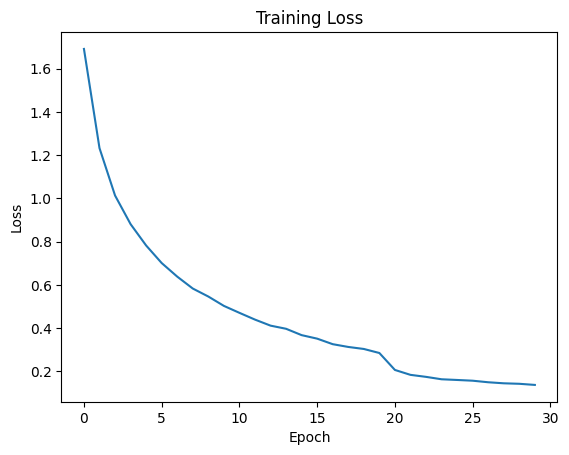

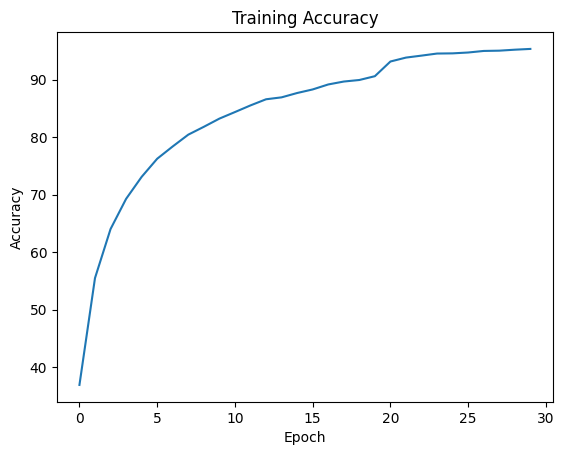

In [9]:
plt.plot(train_loss_list)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(train_acc_list)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()